In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [ ]:
vocab_size=10000
max_length=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)
x_train=pad_sequences(x_train,maxlen=max_length)
x_test=pad_sequences(x_test,maxlen=max_length)
print(x_train.shape,x_test.shape)

(25000, 200) (25000, 200)


In [ ]:
model=Sequential([
    Embedding(vocab_size,64,input_length=max_length),
    SimpleRNN(64),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(x_train,y_train,epochs=3,batch_size=128,validation_split=0.2)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.6440 - loss: 0.6168 - val_accuracy: 0.8012 - val_loss: 0.4544
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.8314 - loss: 0.3896 - val_accuracy: 0.8394 - val_loss: 0.3891
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9032 - loss: 0.2467 - val_accuracy: 0.7796 - val_loss: 0.4845


In [ ]:
loss,acc=model.evaluate(x_test,y_test)
print("Test Accuracy:",acc)
pred=(model.predict(x_test)>0.5).astype(int)
print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1:",f1_score(y_test,pred))
print("Confusion Matrix\n",confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7791 - loss: 0.4848
Test Accuracy: 0.7791200280189514
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
Accuracy: 0.77912
Precision: 0.7681371042114971
Recall: 0.7996
F1: 0.7835528378802132
Confusion Matrix
 [[9483 3017]
 [2505 9995]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.77     12500
           1       0.77      0.80      0.78     12500

    accuracy                           0.78     25000
   macro avg       0.78      0.78      0.78     25000
weighted avg       0.78      0.78      0.78     25000



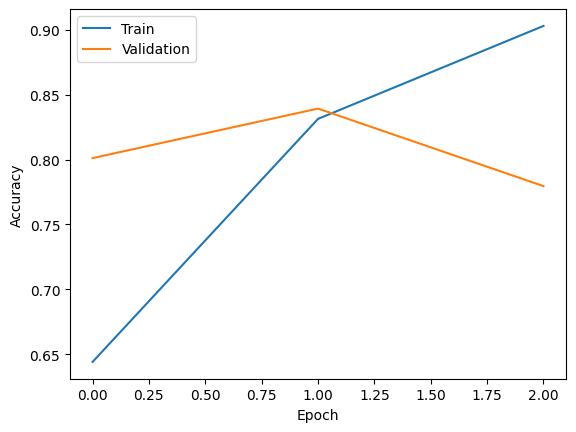

In [ ]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Classify a new review

In [ ]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Standard word_index from Keras
word_index = imdb.get_word_index()

def classify_review(text, model, vocab_size, max_length):
    # 1. Clean: keep only letters and spaces, then tokenize
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)

    # 2. Map to indices
    # Keras IMDb mapping: 0=PAD, 1=START, 2=OOV, 3=Index_From
    # So actual index = word_index[word] + 3
    indexed_review = [1] # Always start with the start-of-sequence token

    for word in words:
        idx = word_index.get(word)
        if idx is not None and (idx + 3) < vocab_size:
            indexed_review.append(idx + 3)
        else:
            indexed_review.append(2) # Unknown

    # 3. Pad sequence
    padded_review = pad_sequences([indexed_review], maxlen=max_length)

    # 4. Predict
    score = model.predict(padded_review, verbose=0)[0][0]
    sentiment = "Positive" if score > 0.5 else "Negative"

    print(f"Review: {text[:80]}...")
    print(f"Predicted Sentiment: {sentiment} (Score: {score:.4f})")
    print("-" * 30)

# Verification
print("Verifying classifications:\n")
classify_review("absolutely shit.", model, vocab_size, max_length)
classify_review("This film was terrible, a complete waste of time. I disliked everything about it.", model, vocab_size, max_length)
classify_review("I really enjoyed the plot and the acting was superb.", model, vocab_size, max_length)

Verifying classifications:

Review: absolutely shit....
Predicted Sentiment: Positive (Score: 0.6290)
------------------------------
Review: this film was terrible, a complete waste of time. i disliked everything about it...
Predicted Sentiment: Negative (Score: 0.0825)
------------------------------
Review: i really enjoyed the plot and the acting was superb....
Predicted Sentiment: Positive (Score: 0.7776)
------------------------------
